<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/Tendencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones

In [2]:
#1. Obtener datos
df = yf.download('GMEXICOB.MX', start='2024-01-01')

/tmp/ipykernel_5488/2034351683.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('GMEXICOB.MX', start='2024-01-01')
[*********************100%***********************]  1 of 1 completed


In [3]:
#2. Calcular Media Móvil Simple de 200 días
df['SMA200'] = df['Close'].rolling(window=200).mean()

In [4]:
#3. Calcular Media Móvil Exponencial de 200 días
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()

In [5]:
#4. Calcular Media Móvil Exponencial de 20 días
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

<Axes: xlabel='Date'>

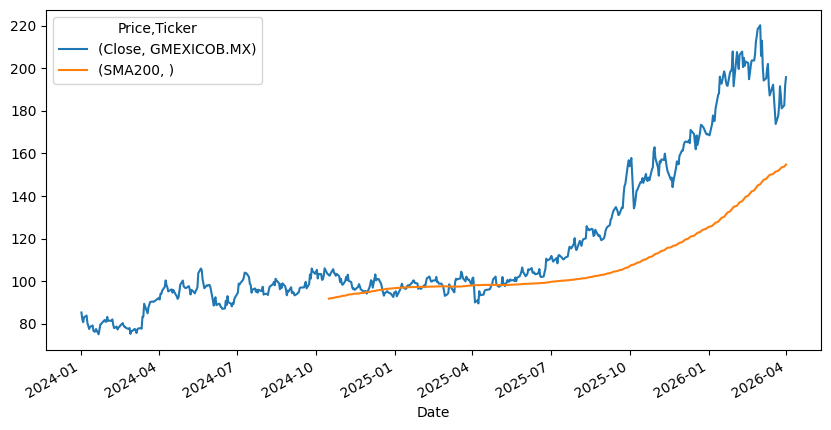

In [6]:
#Visualizar
df[['Close', 'SMA200']].plot(figsize=(10,5))

<Axes: xlabel='Date'>

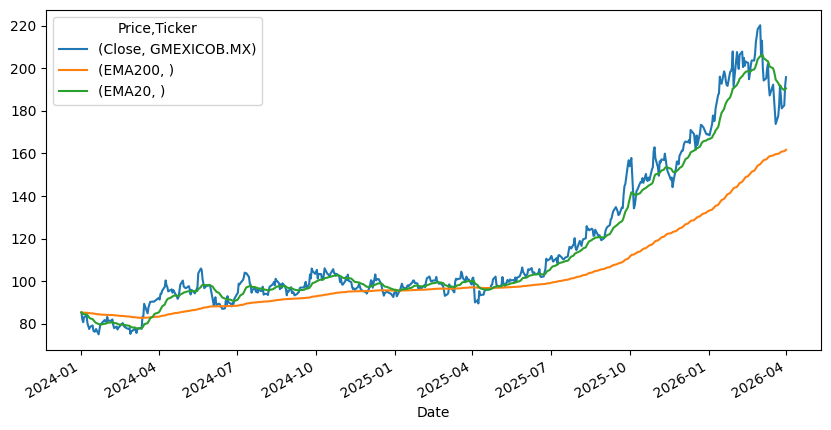

In [7]:
#Visualizar
df[['Close', 'EMA200', 'EMA20']].plot(figsize=(10,5))

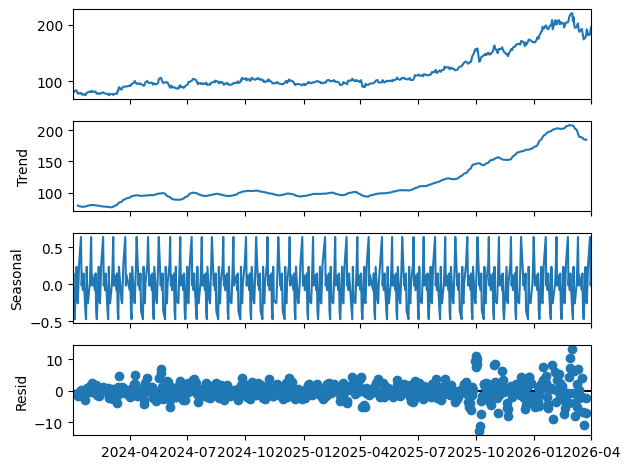

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Cargar datos de acciones
# 2. Descomponer
result = seasonal_decompose(df['Close'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()


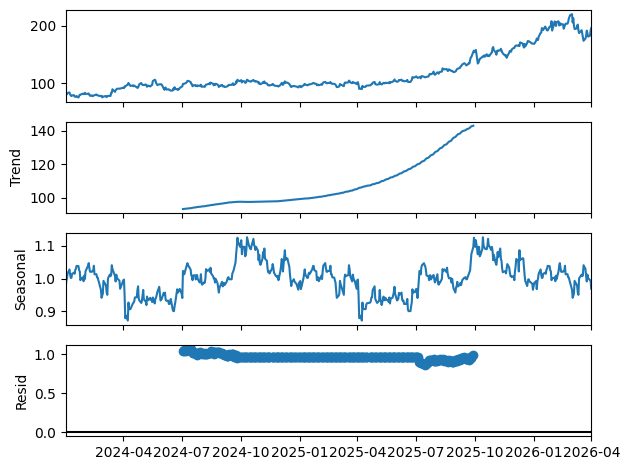

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Cargar datos de acciones
# 2. Descomponer
result = seasonal_decompose(df['Close'], model='multiplicative', period=252) # 252 días hábiles en un año
result.plot()
plt.show()
